# W3D3 - Categorical Analysis

Analyzing the categorical `department` feature by counts and by average values, and presenting the results visually.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Synthetic "employees" dataset - self-contained, no internet needed
rng = np.random.default_rng(seed=42)
n = 200

departments = rng.choice(
    ["Engineering", "Sales", "Marketing", "HR"], size=n, p=[0.4, 0.3, 0.2, 0.1]
)
years_experience = np.clip(rng.normal(6, 3.5, size=n), 0, 25).round(1)

# Base salary driven by department + experience, plus a few high outliers
base_salary = {
    "Engineering": 85000, "Sales": 65000, "Marketing": 60000, "HR": 58000,
}
salary = np.array([base_salary[d] for d in departments]) \
    + years_experience * 1800 \
    + rng.normal(0, 5000, size=n)
# Inject a handful of high-earner outliers to make mean/median diverge
outlier_idx = rng.choice(n, size=6, replace=False)
salary[outlier_idx] += rng.uniform(60000, 120000, size=6)
salary = salary.round(0)

satisfaction_score = np.clip(rng.normal(7, 1.5, size=n), 1, 10).round(1)

df = pd.DataFrame({
    "department": departments,
    "years_experience": years_experience,
    "salary": salary,
    "satisfaction_score": satisfaction_score,
})

df.head()

,department,years_experience,salary,satisfaction_score
0,Marketing,8.3,78741.0,4.5
1,Sales,4.6,74426.0,7.8
2,Marketing,6.0,73450.0,5.4
3,Sales,5.4,71197.0,7.4
4,Engineering,7.2,97062.0,4.9


## Counts by category

department
Engineering    79
Sales          63
Marketing      42
HR             16
Name: count, dtype: int64


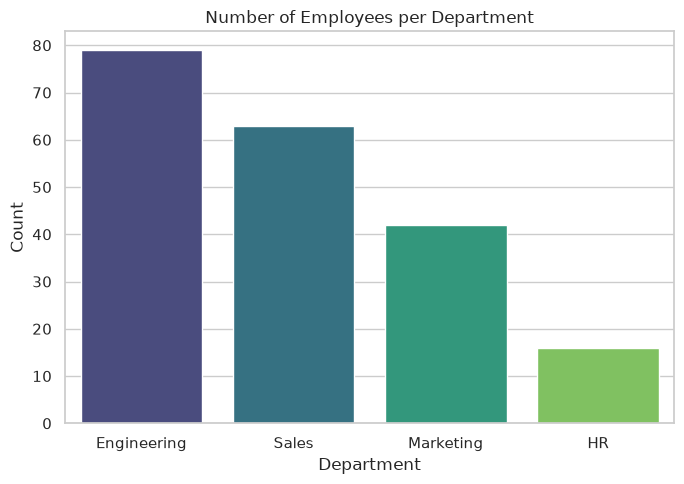

In [3]:
dept_counts = df["department"].value_counts()
print(dept_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=dept_counts.index, y=dept_counts.values, hue=dept_counts.index,
            palette="viridis", legend=False)
plt.title("Number of Employees per Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("categorical_counts_W3D3.png", dpi=150)
plt.show()

## Averages by category

In [3]:
dept_avg = df.groupby("department").agg(
    avg_salary=("salary", "mean"),
    avg_experience=("years_experience", "mean"),
    avg_satisfaction=("satisfaction_score", "mean"),
).round(1).sort_values("avg_salary", ascending=False)
dept_avg

,avg_salary,avg_experience,avg_satisfaction
department,,,
Engineering,97490.5,5.3,6.9
Sales,81145.2,6.5,6.8
Marketing,72151.8,6.6,6.9
HR,69508.6,7.3,7.6


In [4]:
plt.figure(figsize=(7, 5))
sns.barplot(x=dept_avg.index, y=dept_avg["avg_salary"], hue=dept_avg.index,
            palette="magma", legend=False)
plt.title("Average Salary by Department")
plt.xlabel("Department")
plt.ylabel("Average Salary ($)")
plt.tight_layout()
plt.savefig("categorical_avg_salary_W3D3.png", dpi=150)
plt.show()

**Takeaway:** combining a count plot with an average-value bar chart
gives a fuller picture than either alone — a department could have a high
average salary but very few employees (small sample, less reliable), which
the count plot makes visible at a glance.